<a href="https://colab.research.google.com/github/osamamohamaed/Myprojects/blob/main/TimeSeries_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8: Time Series Forecasting Using Deep Learning
---

## 🎯 Objectives
By the end of this lab, you will be able to:
- Understand how time-series data works and why it needs special treatment.
- Preprocess stock market data and create sliding window sequences.
- Build and train an **LSTM** model using PyTorch.
- Build and train a simple **TCN** (Temporal Convolutional Network) using PyTorch.
- Compare both models and evaluate their performance.

---

## 📦 What Libraries Do We Need?
| Library | Purpose |
|---|---|
| `pandas` | Load and manipulate data |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Visualize data and results |
| `sklearn` | Normalize data |
| `torch` | Build and train deep learning models |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

---
## Data Preprocessing

### What are we doing here?
1. **Load** the CSV file into a pandas DataFrame.
2. **Inspect** the data to understand its structure.
3. **Handle** any missing values.
4. **Visualize** the `Close_Price` over time.
5. **Normalize** the data so all values are between 0 and 1 (important for neural networks).
6. **Create sequences** using a **sliding window** — this is how we turn raw prices into (input → output) training pairs.

### 🪟 What is a Sliding Window?
Imagine we look at the last **20 days** of prices to predict the price on **day 21**.
Then we slide the window by one day: use days 2–21 to predict day 22, and so on.

```
Window size = 3, Forecast = 1 step ahead

Day:  [1, 2, 3] → predict Day 4
Day:  [2, 3, 4] → predict Day 5
Day:  [3, 4, 5] → predict Day 6
```

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kundanbedmutha/core-financial-time-series-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.04M/1.04M [00:00<00:00, 1.11MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kundanbedmutha/core-financial-time-series-dataset/versions/1


In [ ]:
import os

os.listdir(path)

['Core_TimeSeries.csv']

In [ ]:
df = pd.read_csv(path + '/Core_TimeSeries.csv')

# Parse the Date column so pandas understands it as dates
df['Date'] = pd.to_datetime(df['Date'])

# Sort rows from oldest to newest date (important for time series!)
df = df.sort_values('Date').reset_index(drop=True)

# Show the first 5 rows
df.head()

,Date,Open_Price,Close_Price,High_Price,Low_Price,Volume,Daily_Return_Pct,Volatility_Range,Market_Cap,SMA_20,SMA_50,RSI_14
0,1902-09-08,100.00,100.50,100.63,99.35,2284489,0.0000,1.28,2.126446e+08,97.354,98.663,50.0
1,1902-09-09,100.50,102.02,102.30,99.49,4522471,1.5124,2.81,3.499216e+08,97.354,98.663,50.0
2,1902-09-10,102.02,101.54,102.18,101.30,3394769,-0.4705,0.88,2.967452e+08,97.354,98.663,50.0
3,1902-09-11,101.54,101.66,102.12,101.07,9834633,0.1182,1.05,3.189160e+08,97.354,98.663,50.0
4,1902-09-12,101.66,99.04,102.61,98.23,4771339,-2.5772,4.38,2.153325e+08,97.354,98.663,50.0


In [ ]:
# Show dataset shape
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 30000 rows, 12 columns


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Date                0
Open_Price          0
Close_Price         0
High_Price          0
Low_Price           0
Volume              0
Daily_Return_Pct    0
Volatility_Range    0
Market_Cap          0
SMA_20              0
SMA_50              0
RSI_14              0
dtype: int64


In [ ]:
print("Close_Price statistics:")
df['Close_Price'].describe()

Close_Price statistics:


,Close_Price
count,30000.000000
mean,61.898006
std,44.070888
min,1.000000
25%,21.370000
50%,56.950000
75%,93.842500
max,174.620000


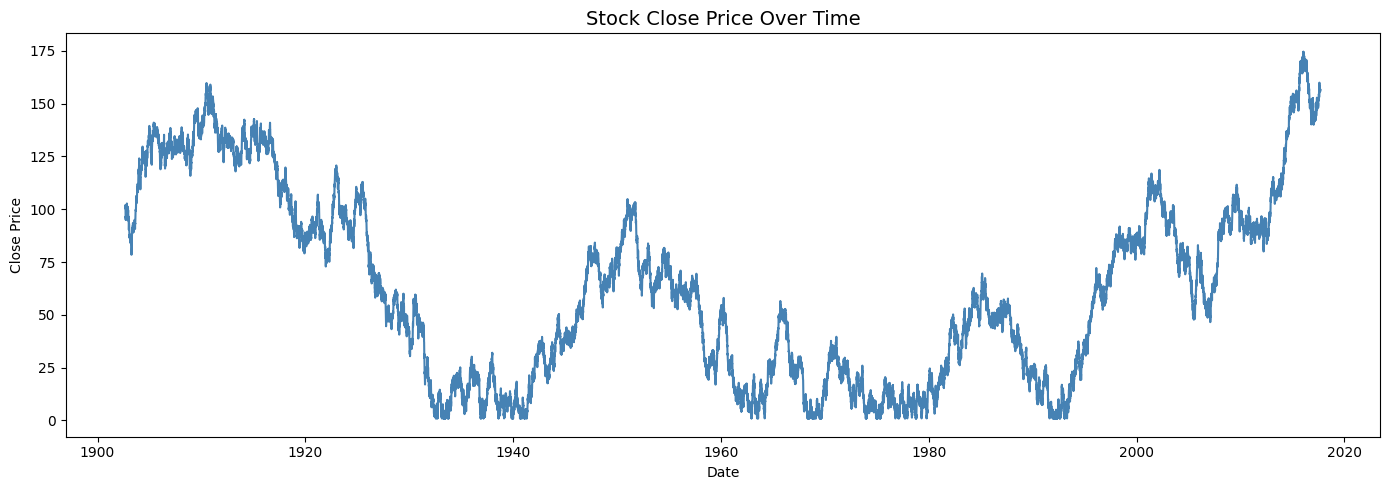

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close_Price'], color='steelblue', linewidth=1.5)
plt.title('Stock Close Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()

In [ ]:
# Also check the basic statistics of Close_Price
print("Close_Price statistics:")
print(df['Close_Price'].describe())

Close_Price statistics:
count    30000.000000
mean        61.898006
std         44.070888
min          1.000000
25%         21.370000
50%         56.950000
75%         93.842500
max        174.620000
Name: Close_Price, dtype: float64


In [ ]:
# Extract only the Close_Price column as a 2D array (required by scaler)
close_prices = df['Close_Price'].values.reshape(-1, 1)

# Create the scaler and fit it to our data
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(close_prices)

# Flatten back to a 1D array for easier handling
scaled_prices = scaled_prices.flatten()

print(f"Original price range: {close_prices.min():.2f} → {close_prices.max():.2f}")
print(f"Scaled price range:   {scaled_prices.min():.2f} → {scaled_prices.max():.2f}")

Original price range: 1.00 → 174.62
Scaled price range:   0.00 → 1.00


In [ ]:
# This function takes:
#   data        → the array of scaled prices
#   window_size → how many past days to use as input
#   forecast_horizon → how many days ahead to predict
#
# It returns:
#   X → list of input windows (past prices)
#   y → list of target values (future prices)

def create_sequences(data, window_size, forecast_horizon=1):
    X = []  # Will hold input sequences
    y = []  # Will hold target values

    # Loop through the data and create each window
    for i in range(len(data) - window_size - forecast_horizon + 1):
        # Input: 'window_size' days starting from index i
        input_window = data[i : i + window_size]

        # Target: the price 'forecast_horizon' days after the window
        target = data[i + window_size + forecast_horizon - 1]

        X.append(input_window)
        y.append(target)

    # Convert lists to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y


WINDOW_SIZE      = 20   # Use 20 past days to predict the next day
FORECAST_HORIZON = 1    # Predict 1 day ahead

# Create sequences from the scaled data
X, y = create_sequences(scaled_prices, WINDOW_SIZE, FORECAST_HORIZON)

print(f"Total sequences created: {len(X)}")
print(f"Each X sample shape: {X[0].shape}  (window of {WINDOW_SIZE} days)")
print(f"Each y sample: a single price value")

Total sequences created: 29980
Each X sample shape: (20,)  (window of 20 days)
Each y sample: a single price value


In [ ]:
# IMPORTANT: For time series, we do NOT shuffle!

# Calculate split index (80% train, 20% test)
split_index = int(len(X) * 0.80)

# Split the data
X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# Shape needed:
#   LSTM  expects: (batch, sequence_length, features)
#   TCN   expects: (batch, features, sequence_length)
# We'll add a dimension for 'features' (= 1, since we only use Close_Price)

# For LSTM: shape → (samples, window_size, 1)
X_train_lstm = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test_lstm  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)

# For TCN: shape → (samples, 1, window_size)
X_train_tcn  = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tcn   = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

# Targets: shape → (samples, 1)
y_train_t    = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test_t     = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(-1)

print("Tensor shapes:")
print(f"X_train_lstm : {X_train_lstm.shape}")
print(f"X_train_tcn  : {X_train_tcn.shape}")
print(f"y_train      : {y_train_t.shape}")

Training samples : 23984
Testing  samples : 5996
Tensor shapes:
X_train_lstm : torch.Size([23984, 20, 1])
X_train_tcn  : torch.Size([23984, 1, 20])
y_train      : torch.Size([23984, 1])


In [ ]:
BATCH_SIZE = 32

# LSTM DataLoaders
train_dataset_lstm = TensorDataset(X_train_lstm, y_train_t)
test_dataset_lstm  = TensorDataset(X_test_lstm,  y_test_t)

train_loader_lstm  = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)
test_loader_lstm   = DataLoader(test_dataset_lstm,  batch_size=BATCH_SIZE, shuffle=False)

# TCN DataLoaders
train_dataset_tcn  = TensorDataset(X_train_tcn, y_train_t)
test_dataset_tcn   = TensorDataset(X_test_tcn,  y_test_t)

train_loader_tcn   = DataLoader(train_dataset_tcn, batch_size=BATCH_SIZE, shuffle=False)
test_loader_tcn    = DataLoader(test_dataset_tcn,  batch_size=BATCH_SIZE, shuffle=False)

---
## Implementing LSTM (Long Short-Term Memory)

### What is an LSTM?
An **LSTM** is a special type of Recurrent Neural Network (RNN) that is very good at learning **long-term patterns** in sequential data like stock prices.

Unlike a regular RNN, an LSTM has **memory cells** that can:
- 🔒 **Keep** important information for a long time.
- 🗑️ **Forget** information that is no longer useful.
- 📤 **Output** relevant information at each step.

### Our LSTM Architecture:
```
Input (20 days of prices)
       ↓
   LSTM Layer  (hidden_size = 64)
       ↓
  Fully Connected Layer (64 → 1)
       ↓
  Output (predicted price for tomorrow)
```

In [ ]:
class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()

        # LSTM layer: processes the sequence step by step
        self.lstm = nn.LSTM(
            input_size  = input_size,   # number of features per time step (1 = Close_Price)
            hidden_size = hidden_size,  # number of memory units
            num_layers  = num_layers,   # how many LSTM layers to stack
            batch_first = True          # input shape: (batch, sequence, features)
        )

        # Fully connected layer: maps LSTM output to a single price prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Run input through LSTM
        # lstm_out shape: (batch, sequence_length, hidden_size)
        lstm_out, _ = self.lstm(x)

        # We only need the output from the LAST time step
        last_step = lstm_out[:, -1, :]   # shape: (batch, hidden_size)

        # Pass through the fully connected layer to get prediction
        prediction = self.fc(last_step)  # shape: (batch, 1)

        return prediction

lstm_model = LSTMModel(
    input_size  = 1,    # we have 1 feature: Close_Price
    hidden_size = 64,   # 64 memory units
    num_layers  = 2,    # 2 stacked LSTM layers
    output_size = 1     # predict 1 value (next day's price)
)

print("LSTM Model Architecture:")
print(lstm_model)

# Count total trainable parameters
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

LSTM Model Architecture:
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Total trainable parameters: 50,497


In [ ]:
import torch
import torch.nn as nn
lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = 64,
            num_layers  = 2,
            batch_first = True
            )

lstm

LSTM(1, 64, num_layers=2, batch_first=True)

In [ ]:
# output, states = lstm(torch.randn(32, 1, 1))

# output.size()

# output = output[:, -1, :]
# output.shape
# print(states[0].shape)
# print(states[1].shape)

In [ ]:
def train_model(model, train_loader, num_epochs=50, learning_rate=0.001):
    """
    Train a PyTorch model.
    Returns:
        loss_history : list of average loss per epoch
        training_time: total seconds spent training
    """

    # Loss function: Mean Squared Error — penalizes large errors
    loss_fn   = nn.MSELoss()

    # Optimizer: Adam adjusts the weights automatically
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    # Record start time
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):

        # Set model to training mode
        model.train()

        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Step 1: Clear previous gradients
            optimizer.zero_grad()

            # Step 2: Forward pass — get predictions
            predictions = model(X_batch)

            # Step 3: Calculate loss
            loss = loss_fn(predictions, y_batch)

            # Step 4: Backward pass — compute gradients
            loss.backward()

            # Step 5: Update weights
            optimizer.step()

            # Accumulate batch loss
            epoch_loss += loss.item()

        # Calculate average loss for this epoch
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        # Print progress every 10 epochs
        if epoch % 10 == 0:
            print(f"  Epoch [{epoch:3d}/{num_epochs}]  Loss: {avg_loss:.6f}")

    training_time = time.time() - start_time
    print(f"\n⏱️  Training finished in {training_time:.2f} seconds")

    return loss_history, training_time

Training LSTM Model...
----------------------------------------
  Epoch [ 10/50]  Loss: 0.001312
  Epoch [ 20/50]  Loss: 0.000543
  Epoch [ 30/50]  Loss: 0.000351
  Epoch [ 40/50]  Loss: 0.000250
  Epoch [ 50/50]  Loss: 0.000198

⏱️  Training finished in 245.73 seconds


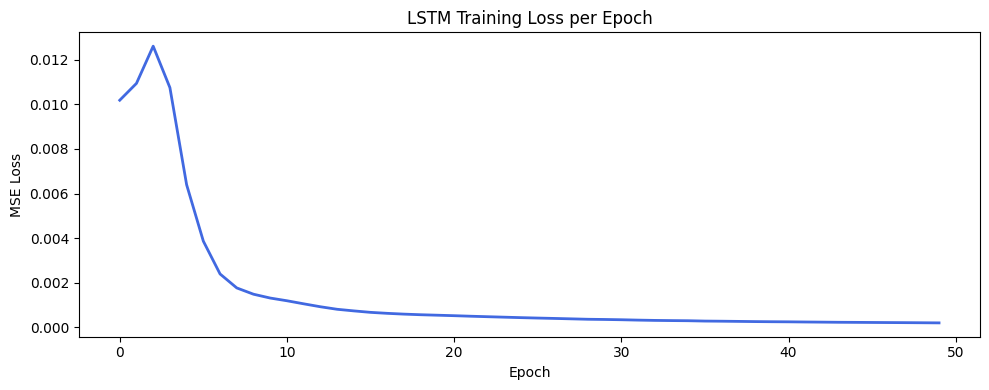

In [ ]:
print("Training LSTM Model...")
print("-" * 40)

lstm_loss_history, lstm_train_time = train_model(
    model         = lstm_model,
    train_loader  = train_loader_lstm,
    num_epochs    = 50,
    learning_rate = 0.001
)

plt.figure(figsize=(10, 4))
plt.plot(lstm_loss_history, color='royalblue', linewidth=2)
plt.title('LSTM Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model(model, test_loader, scaler):
    """
    Evaluate a trained model on test data.
    Returns:
        all_preds : numpy array of predicted prices (original scale)
        all_true  : numpy array of true prices (original scale)
        mae       : Mean Absolute Error
        rmse      : Root Mean Squared Error
    """

    # Set model to evaluation mode (disables dropout etc.)
    model.eval()

    all_preds = []  # Store all predictions
    all_true  = []  # Store all true values

    # torch.no_grad() tells PyTorch not to track gradients (saves memory)
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            all_preds.append(preds.numpy())
            all_true.append(y_batch.numpy())

    # Stack all batch results into one array
    all_preds = np.concatenate(all_preds, axis=0)
    all_true  = np.concatenate(all_true,  axis=0)

    # Inverse-transform: convert scaled values back to original prices
    all_preds_orig = scaler.inverse_transform(all_preds)
    all_true_orig  = scaler.inverse_transform(all_true)

    # Calculate evaluation metrics
    mae  = mean_absolute_error(all_true_orig, all_preds_orig)
    rmse = np.sqrt(mean_squared_error(all_true_orig, all_preds_orig))

    return all_preds_orig, all_true_orig, mae, rmse

LSTM Model Performance on Test Set:
MAE  (Mean Absolute Error): 4.2574
RMSE (Root Mean Squared Error): 8.6685


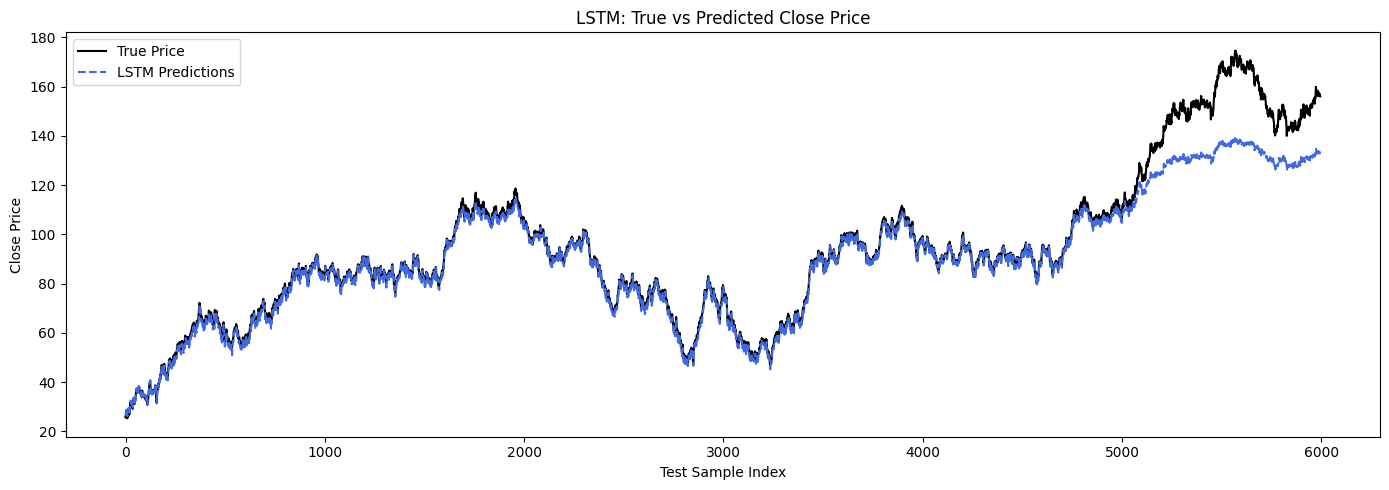

In [ ]:
lstm_preds, true_values, lstm_mae, lstm_rmse = evaluate_model(
    model       = lstm_model,
    test_loader = test_loader_lstm,
    scaler      = scaler
)

print("LSTM Model Performance on Test Set:")
print(f"MAE  (Mean Absolute Error): {lstm_mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {lstm_rmse:.4f}")

# Plot LSTM predictions vs true values
plt.figure(figsize=(14, 5))
plt.plot(true_values,  label='True Price',       color='black',     linewidth=1.5)
plt.plot(lstm_preds,   label='LSTM Predictions', color='royalblue', linewidth=1.5, linestyle='--')
plt.title('LSTM: True vs Predicted Close Price')
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

---
## Implementing a Temporal Convolutional Network (TCN)

### What is a TCN?
A **Temporal Convolutional Network (TCN)** uses **1D convolution layers** to capture patterns in sequences. Instead of processing data step-by-step like LSTM, TCN processes the **entire window at once** using convolution filters.

### Key idea — Dilated Convolutions:
Normal convolution looks at **nearby** time steps.
**Dilated** convolution skips some steps to look at a **wider range** of the past with fewer computations.

```
Dilation = 1:  [■ ■ ■ ■ ■]  — looks at 5 consecutive steps
Dilation = 2:  [■ _ ■ _ ■]  — looks at steps 0, 2, 4 (covers more history!)
Dilation = 4:  [■ _ _ _ ■]  — looks at steps 0 and 4
```

### Our Simple TCN Architecture:
```
Input (1 feature, 20 time steps)
       ↓
  Conv1d (dilation=1)
       ↓
  Conv1d (dilation=2)
       ↓
  Global Average Pooling
       ↓
  Fully Connected Layer → 1 output
```

In [ ]:
class SimpleTCN(nn.Module):

    def __init__(self, input_channels, num_filters, kernel_size, output_size):
        super(SimpleTCN, self).__init__()

        # First convolutional block (dilation=1)
        # padding keeps the output length the same as the input length
        self.conv1 = nn.Conv1d(
            in_channels  = input_channels,
            out_channels = num_filters,
            kernel_size  = kernel_size,
            dilation     = 1,
            padding      = (kernel_size - 1) * 1  # causal padding
        )
        self.relu1 = nn.ReLU()

        # Second convolutional block (dilation=2)
        self.conv2 = nn.Conv1d(
            in_channels  = num_filters,
            out_channels = num_filters,
            kernel_size  = kernel_size,
            dilation     = 2,
            padding      = (kernel_size - 1) * 2  # causal padding
        )
        self.relu2 = nn.ReLU()

        # Fully connected layer for final prediction
        self.fc = nn.Linear(num_filters, output_size)

    def forward(self, x):
        # x shape: (batch, 1, window_size)

        # Pass through first conv block
        out = self.conv1(x)
        out = out[:, :, :x.shape[2]]  # trim to original length (causal conv)
        out = self.relu1(out)

        # Pass through second conv block
        out = self.conv2(out)
        out = out[:, :, :x.shape[2]]  # trim to original length
        out = self.relu2(out)

        # Global Average Pooling: average across the time dimension
        # Shape: (batch, num_filters, time) → (batch, num_filters)
        out = out.mean(dim=2)

        # Final prediction
        prediction = self.fc(out)   # shape: (batch, 1)

        return prediction


tcn_model = SimpleTCN(
    input_channels = 1,    # 1 feature: Close_Price
    num_filters    = 64,   # number of convolution filters
    kernel_size    = 3,    # filter looks at 3 time steps at a time
    output_size    = 1     # predict 1 value
)

print("TCN Model Architecture:")
print(tcn_model)

total_params_tcn = sum(p.numel() for p in tcn_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params_tcn}")

TCN Model Architecture:
SimpleTCN(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(2,))
  (relu1): ReLU()
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
  (relu2): ReLU()
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 12673


Training TCN Model...
----------------------------------------
  Epoch [ 10/50]  Loss: 0.000617
  Epoch [ 20/50]  Loss: 0.000467
  Epoch [ 30/50]  Loss: 0.000419
  Epoch [ 40/50]  Loss: 0.000353
  Epoch [ 50/50]  Loss: 0.000309

⏱️  Training finished in 122.25 seconds


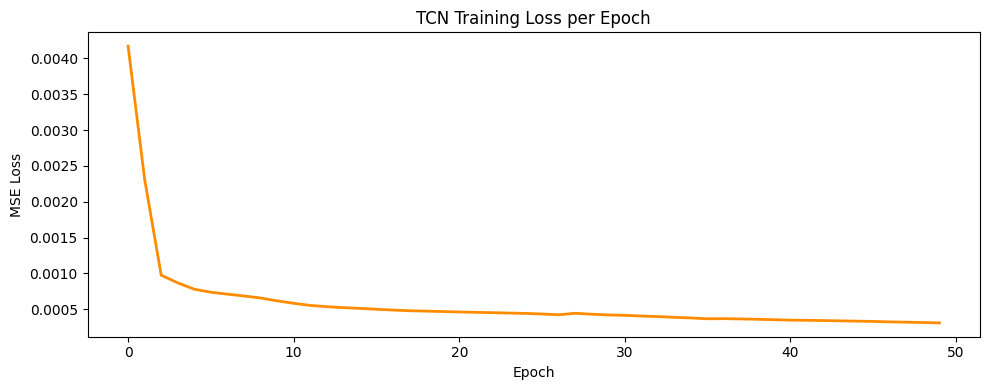

In [ ]:
print("Training TCN Model...")
print("-" * 40)

tcn_loss_history, tcn_train_time = train_model(
    model         = tcn_model,
    train_loader  = train_loader_tcn,
    num_epochs    = 50,
    learning_rate = 0.001
)

plt.figure(figsize=(10, 4))
plt.plot(tcn_loss_history, color='darkorange', linewidth=2)
plt.title('TCN Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

TCN Model Performance on Test Set:
   MAE  (Mean Absolute Error)       : 10.8841
   RMSE (Root Mean Squared Error)   : 13.6263


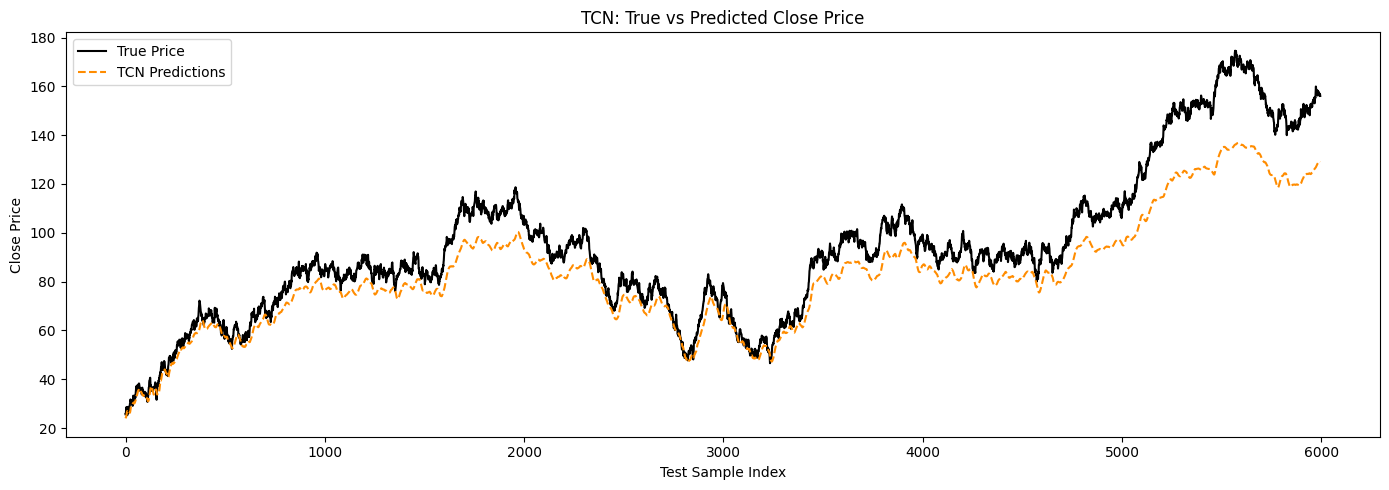

In [ ]:
tcn_preds, true_values, tcn_mae, tcn_rmse = evaluate_model(
    model       = tcn_model,
    test_loader = test_loader_tcn,
    scaler      = scaler
)

print("TCN Model Performance on Test Set:")
print(f"   MAE  (Mean Absolute Error)       : {tcn_mae:.4f}")
print(f"   RMSE (Root Mean Squared Error)   : {tcn_rmse:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(true_values, label='True Price',      color='black',      linewidth=1.5)
plt.plot(tcn_preds,   label='TCN Predictions', color='darkorange', linewidth=1.5, linestyle='--')
plt.title('TCN: True vs Predicted Close Price')
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

Metric                               LSTM        TCN
MAE                                4.2574    10.8841
RMSE                               8.6685    13.6263
Training Time (seconds)            245.73     122.25


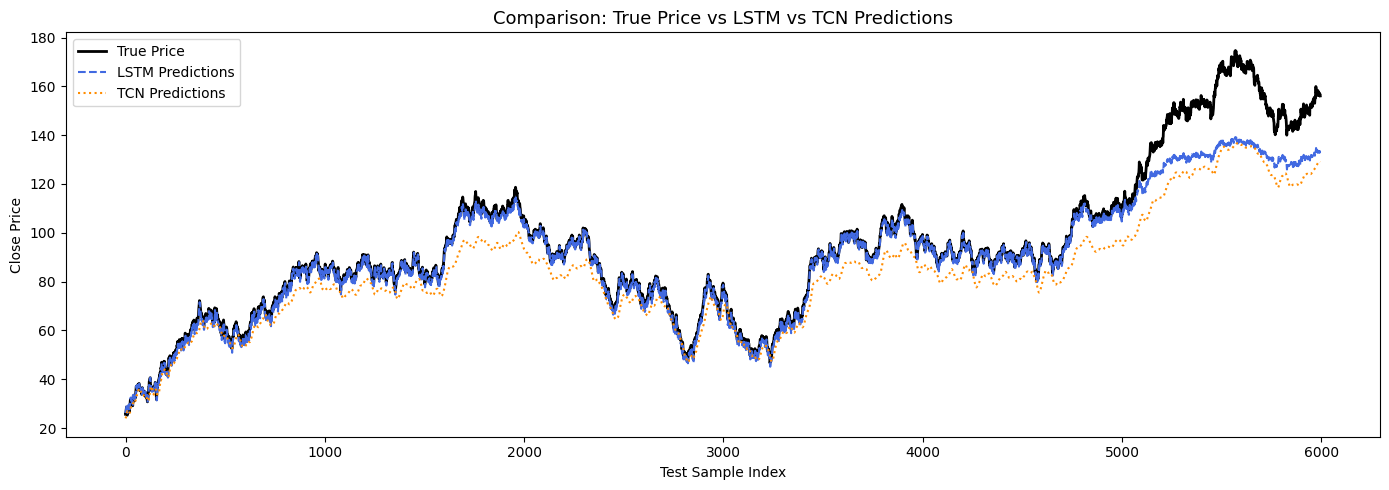

In [ ]:
print("=" * 55)
print(f"{'Metric':<30} {'LSTM':>10} {'TCN':>10}")
print("=" * 55)
print(f"{'MAE':<30} {lstm_mae:>10.4f} {tcn_mae:>10.4f}")
print(f"{'RMSE':<30} {lstm_rmse:>10.4f} {tcn_rmse:>10.4f}")
print(f"{'Training Time (seconds)':<30} {lstm_train_time:>10.2f} {tcn_train_time:>10.2f}")
print("=" * 55)

plt.figure(figsize=(14, 5))

plt.plot(true_values,  label='True Price',       color='black',      linewidth=2.0)
plt.plot(lstm_preds,   label='LSTM Predictions', color='royalblue',  linewidth=1.5, linestyle='--')
plt.plot(tcn_preds,    label='TCN Predictions',  color='darkorange', linewidth=1.5, linestyle=':')

plt.title('Comparison: True Price vs LSTM vs TCN Predictions', fontsize=13)
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

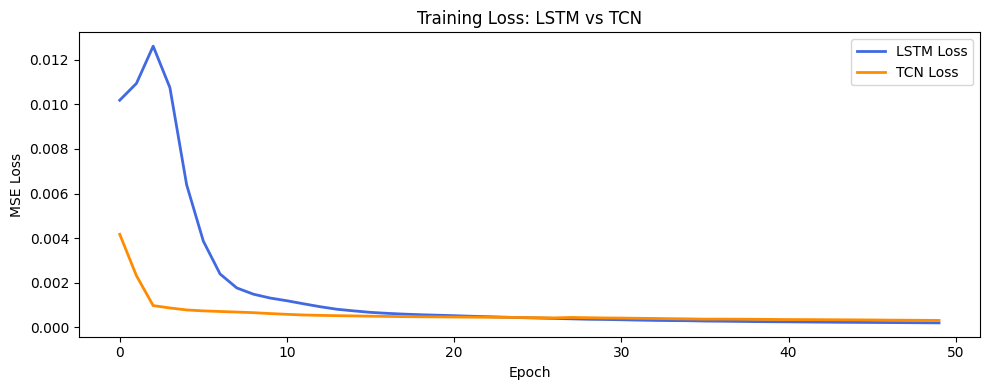

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_loss_history, label='LSTM Loss', color='royalblue',  linewidth=2)
plt.plot(tcn_loss_history,  label='TCN Loss',  color='darkorange', linewidth=2)
plt.title('Training Loss: LSTM vs TCN')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

Experiment Settings:
Window size      : 30 days
Forecast horizon : 7 day(s) ahead

Training Experimental LSTM...
  Epoch [ 10/50]  Loss: 0.001675
  Epoch [ 20/50]  Loss: 0.001049
  Epoch [ 30/50]  Loss: 0.000820
  Epoch [ 40/50]  Loss: 0.000686
  Epoch [ 50/50]  Loss: 0.000601

⏱️  Training finished in 226.05 seconds
Experimental LSTM Results:
   Window size      : 30
   Forecast horizon : 7 day(s)
   MAE              : 8.8254
   RMSE             : 13.2889


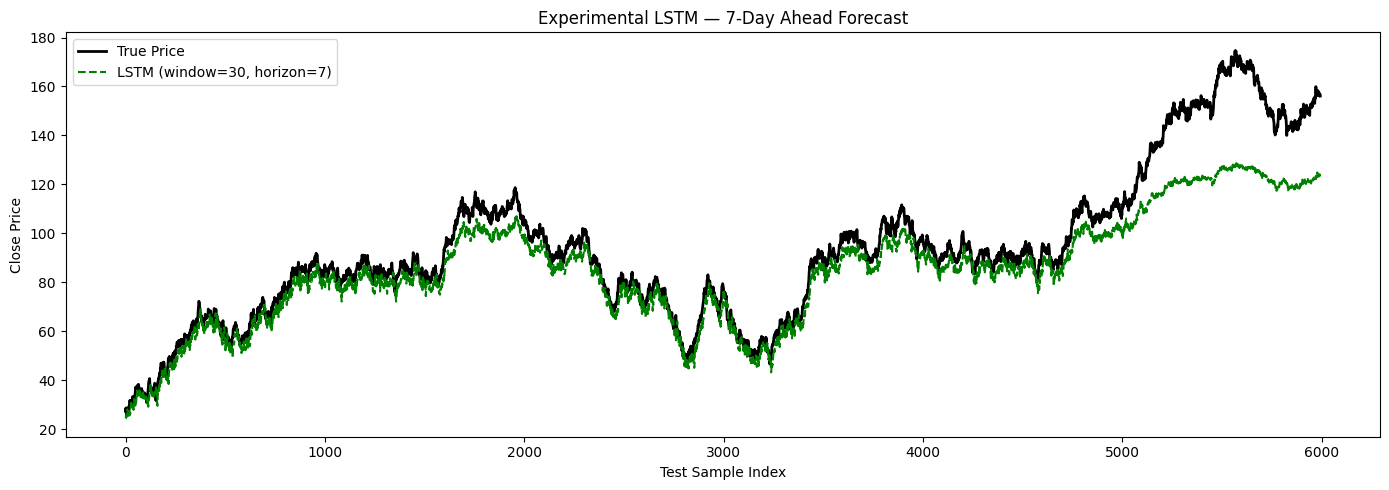

In [ ]:
# --- 🔧 Change these values to experiment ---
EXP_WINDOW_SIZE      = 30   # Try: 10, 20, 30, 60
EXP_FORECAST_HORIZON = 7    # Try: 1, 3, 7 (7 = predict 1 week ahead!)
EXP_EPOCHS           = 50

print(f"Experiment Settings:")
print(f"Window size      : {EXP_WINDOW_SIZE} days")
print(f"Forecast horizon : {EXP_FORECAST_HORIZON} day(s) ahead")
print("")

# Step 1: Create new sequences with the new settings
X_exp, y_exp = create_sequences(scaled_prices, EXP_WINDOW_SIZE, EXP_FORECAST_HORIZON)

# Step 2: Split into train / test (same 80/20 split)
split_exp = int(len(X_exp) * 0.80)
X_train_exp = X_exp[:split_exp]
X_test_exp  = X_exp[split_exp:]
y_train_exp = y_exp[:split_exp]
y_test_exp  = y_exp[split_exp:]

# Step 3: Convert to tensors for LSTM
X_train_exp_t = torch.tensor(X_train_exp, dtype=torch.float32).unsqueeze(-1)
X_test_exp_t  = torch.tensor(X_test_exp,  dtype=torch.float32).unsqueeze(-1)
y_train_exp_t = torch.tensor(y_train_exp, dtype=torch.float32).unsqueeze(-1)
y_test_exp_t  = torch.tensor(y_test_exp,  dtype=torch.float32).unsqueeze(-1)

# Step 4: Create DataLoaders
loader_train_exp = DataLoader(TensorDataset(X_train_exp_t, y_train_exp_t), batch_size=32, shuffle=False)
loader_test_exp  = DataLoader(TensorDataset(X_test_exp_t,  y_test_exp_t),  batch_size=32, shuffle=False)

# Step 5: Build a new LSTM model
lstm_exp = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1)

# Step 6: Train
print("Training Experimental LSTM...")
exp_loss_history, exp_train_time = train_model(
    model=lstm_exp, train_loader=loader_train_exp, num_epochs=EXP_EPOCHS
)

# Step 7: Evaluate
exp_preds, exp_true, exp_mae, exp_rmse = evaluate_model(lstm_exp, loader_test_exp, scaler)

print("Experimental LSTM Results:")
print(f"   Window size      : {EXP_WINDOW_SIZE}")
print(f"   Forecast horizon : {EXP_FORECAST_HORIZON} day(s)")
print(f"   MAE              : {exp_mae:.4f}")
print(f"   RMSE             : {exp_rmse:.4f}")

# Plot results
plt.figure(figsize=(14, 5))
plt.plot(exp_true,  label='True Price',                       color='black',   linewidth=2)
plt.plot(exp_preds, label=f'LSTM (window={EXP_WINDOW_SIZE}, horizon={EXP_FORECAST_HORIZON})',
         color='green', linewidth=1.5, linestyle='--')
plt.title(f'Experimental LSTM — {EXP_FORECAST_HORIZON}-Day Ahead Forecast')
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 65)
print("               FULL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<35} {'MAE':>8} {'RMSE':>8} {'Time(s)':>8}")
print("-" * 65)
print(f"{'LSTM  (window=20, horizon=1)':<35} {lstm_mae:>8.4f} {lstm_rmse:>8.4f} {lstm_train_time:>8.2f}")
print(f"{'TCN   (window=20, horizon=1)':<35} {tcn_mae:>8.4f}  {tcn_rmse:>8.4f} {tcn_train_time:>8.2f}")
print(f"{'LSTM  (Experiment)':<35} {exp_mae:>8.4f} {exp_rmse:>8.4f} {exp_train_time:>8.2f}")
print("=" * 65)


               FULL RESULTS SUMMARY
Model                                    MAE     RMSE  Time(s)
-----------------------------------------------------------------
LSTM  (window=20, horizon=1)          4.2574   8.6685   245.73
TCN   (window=20, horizon=1)         10.8841   13.6263   122.25
LSTM  (Experiment)                    8.8254  13.2889   226.05
